# Diabetes Dataset: Exploratory Analysis and Statistical Testing

This notebook examines the relationship between Glucose level and diabetes Outcome with a contingency table and chi-square test, then explores the dataset further after removing biologically invalid zero readings, and applies feature scaling.

## Contingency Table: Glucose vs Outcome (exercise 9-2)

In [74]:
# Build a contingency table of Glucose level against diabetes Outcome
dfd=pd.read_csv('diabetes.csv')
observed=pd.crosstab(dfd["Glucose"],dfd["Outcome"],margins=True)
observed

Outcome,0,1,All
Glucose,,,
0,3,2,5
44,1,0,1
56,1,0,1
57,2,0,2
61,1,0,1
62,1,0,1
65,1,0,1
67,1,0,1
68,3,0,3


## Chi-Square Test of Independence (exercise 9-3)

In [76]:
# Chi-square test of independence between Glucose and Outcome
import scipy.stats
scipy.stats.chi2_contingency(observed)

(269.7332418198132,
 0.5274453807916104,
 272,
 array([[3.25520833e+00, 1.74479167e+00, 5.00000000e+00],
        [6.51041667e-01, 3.48958333e-01, 1.00000000e+00],
        [6.51041667e-01, 3.48958333e-01, 1.00000000e+00],
        [1.30208333e+00, 6.97916667e-01, 2.00000000e+00],
        [6.51041667e-01, 3.48958333e-01, 1.00000000e+00],
        [6.51041667e-01, 3.48958333e-01, 1.00000000e+00],
        [6.51041667e-01, 3.48958333e-01, 1.00000000e+00],
        [6.51041667e-01, 3.48958333e-01, 1.00000000e+00],
        [1.95312500e+00, 1.04687500e+00, 3.00000000e+00],
        [2.60416667e+00, 1.39583333e+00, 4.00000000e+00],
        [6.51041667e-01, 3.48958333e-01, 1.00000000e+00],
        [1.95312500e+00, 1.04687500e+00, 3.00000000e+00],
        [2.60416667e+00, 1.39583333e+00, 4.00000000e+00],
        [1.30208333e+00, 6.97916667e-01, 2.00000000e+00],
        [1.30208333e+00, 6.97916667e-01, 2.00000000e+00],
        [1.30208333e+00, 6.97916667e-01, 2.00000000e+00],
        [2.60416667e+00, 

## Exploratory Analysis After Removing Invalid Zero Readings (exercise 10-1)

In [55]:
# Remove biologically invalid zero readings for Glucose and BloodPressure
da=pd.read_csv('diabetes.csv')
da.drop( da[ da['Glucose'] == 0 ].index , inplace=True)
da.drop( da[ da['BloodPressure'] == 0 ].index , inplace=True)

In [73]:
# Number of distinct values per column after cleaning
da.nunique()

Pregnancies                  17
Glucose                     135
BloodPressure                46
SkinThickness                51
Insulin                     186
BMI                         246
DiabetesPedigreeFunction    502
Age                          51
Outcome                       2
dtype: int64

In [84]:
# Frequency of each value of Pregnancies
da.groupby('Pregnancies').size()

Pregnancies
0     101
1     131
2      96
3      72
4      65
5      56
6      46
7      42
8      37
9      28
10     22
11     10
12      9
13      9
14      2
15      1
17      1
dtype: int64

In [75]:
# Frequency of each value of Glucose
da.groupby('Glucose').size()

Glucose
44      1
56      1
57      2
61      1
62      1
65      1
67      1
68      3
71      4
72      1
73      2
74      3
75      2
76      2
77      2
78      4
79      3
80      5
81      6
82      3
83      6
84      9
85      7
86      3
87      6
88      9
89      6
90     10
91      8
92      9
       ..
168     4
169     1
170     2
171     3
172     1
173     6
174     2
175     2
176     2
177     1
178     1
179     5
180     4
181     5
182     1
183     2
184     3
186     1
187     4
188     2
189     4
190     1
191     1
193     2
194     3
195     2
196     3
197     4
198     1
199     1
Length: 135, dtype: int64

In [83]:
# Frequency of each value of BloodPressure
da.groupby('BloodPressure').size()

BloodPressure
24      1
30      2
38      1
40      1
44      4
46      2
48      4
50     13
52     11
54     11
55      2
56     12
58     21
60     37
61      1
62     34
64     43
65      7
66     30
68     43
70     57
72     44
74     51
75      8
76     39
78     45
80     39
82     30
84     23
85      6
86     21
88     25
90     22
92      8
94      6
95      1
96      4
98      3
100     3
102     1
104     2
106     3
108     2
110     3
114     1
122     1
dtype: int64

In [85]:
# Frequency of each value of SkinThickness
da.groupby('SkinThickness').size()

SkinThickness
0     194
7       2
8       2
10      5
11      6
12      7
13     11
14      6
15     14
16      6
17     14
18     20
19     18
20     11
21     10
22     16
23     21
24     12
25     16
26     16
27     23
28     20
29     17
30     26
31     19
32     30
33     20
34      8
35     14
36     14
37     16
38      7
39     18
40     16
41     14
42     11
43      6
44      5
45      6
46      8
47      4
48      4
49      3
50      3
51      1
52      2
54      2
56      1
60      1
63      1
99      1
dtype: int64

In [78]:
# Frequency of each value of Insulin
da.groupby('Insulin').size()

Insulin
0      335
14       1
15       1
16       1
18       2
22       1
23       1
25       1
29       1
32       1
36       3
37       2
38       1
40       2
41       1
42       1
43       1
44       3
45       3
46       1
48       3
49       5
50       3
51       1
52       1
53       2
54       4
55       2
56       5
57       2
      ... 
321      1
325      3
326      1
328      1
330      1
335      1
342      1
360      1
370      1
375      1
387      1
392      1
402      1
415      1
440      1
465      1
474      1
478      1
480      2
485      1
495      2
510      1
540      1
543      1
545      1
579      1
600      1
680      1
744      1
846      1
Length: 186, dtype: int64

In [79]:
# Frequency of each value of BMI
da.groupby('BMI').size()

BMI
0.0     4
18.2    3
18.4    1
19.1    1
19.3    1
19.4    1
19.5    2
19.6    2
19.9    1
20.0    1
20.1    1
20.4    2
20.8    2
21.0    2
21.1    3
21.2    1
21.7    1
21.8    5
21.9    3
22.1    2
22.2    1
22.3    1
22.4    2
22.5    3
22.6    2
22.7    1
22.9    2
23.0    2
23.1    4
23.2    3
       ..
44.5    2
44.6    1
45.0    1
45.2    1
45.3    3
45.4    1
45.5    1
45.6    2
45.7    1
45.8    1
46.1    2
46.2    2
46.3    1
46.5    1
46.7    1
46.8    2
47.9    2
48.3    1
48.8    1
49.3    1
49.6    1
49.7    1
50.0    1
52.3    1
52.9    1
53.2    1
55.0    1
57.3    1
59.4    1
67.1    1
Length: 246, dtype: int64

In [80]:
# Frequency of each value of DiabetesPedigreeFunction
da.groupby('DiabetesPedigreeFunction').size()

DiabetesPedigreeFunction
0.078    1
0.084    1
0.085    2
0.088    2
0.089    1
0.092    1
0.096    1
0.100    1
0.101    1
0.107    1
0.115    1
0.118    1
0.121    2
0.122    1
0.123    1
0.126    2
0.127    2
0.128    2
0.129    2
0.130    1
0.133    1
0.134    1
0.135    1
0.136    1
0.137    2
0.138    1
0.140    1
0.141    2
0.142    3
0.143    2
        ..
1.189    1
1.191    1
1.213    1
1.222    1
1.224    2
1.251    1
1.258    1
1.268    1
1.282    1
1.292    1
1.318    1
1.321    1
1.353    1
1.390    1
1.391    1
1.394    1
1.400    1
1.441    1
1.461    1
1.476    1
1.600    1
1.698    1
1.699    1
1.731    1
1.781    1
1.893    1
2.137    1
2.288    1
2.329    1
2.420    1
Length: 502, dtype: int64

In [81]:
# Frequency of each value of Age
da.groupby('Age').size()

Age
21    61
22    67
23    35
24    44
25    44
26    31
27    31
28    33
29    27
30    19
31    21
32    15
33    17
34    14
35    10
36    15
37    17
38    15
39    12
40    12
41    19
42    18
43    13
44     6
45    15
46    13
47     6
48     5
49     5
50     8
51     8
52     8
53     5
54     6
55     4
56     3
57     5
58     7
59     3
60     5
61     2
62     4
63     4
64     1
65     3
66     4
67     3
68     1
69     2
70     1
81     1
dtype: int64

In [86]:
# Class balance of the Outcome target
da.groupby('Outcome').size()

Outcome
0    478
1    250
dtype: int64

In [87]:
# Missing value count per column
da.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [88]:
# Data types of each column
da.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

## Linear Regression Model (exercise 10-2)

Coefficients: 
 [ 2.32444087e-02  5.98264109e-03 -1.21594186e-04  1.35480351e-02
  1.79299264e-01]
Variance score: 0.3487983549571473


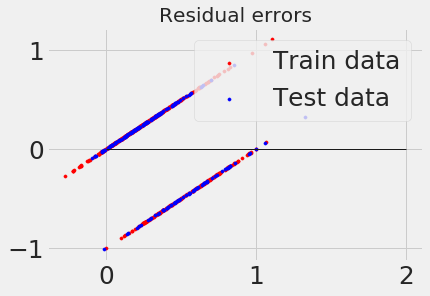

Mean Absolute Error (MAE)         : 0.319842252561717
Mean Squared Error (MSE) : 0.1484686276827564
Root Mean Squared Error (RMSE) : 0.3853162696834334
Root Mean Squared Error (RMSE) : 0.3853162696834334
Mean Absolute Perc. Error (MAPE) : inf


In [56]:
# Reload the raw data, remove invalid zero readings, and fit a simple
# linear regression model to predict Outcome from a subset of features
from statsmodels.tools.eval_measures import mse, rmse
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn import datasets, linear_model, metrics 
import pandas as pd
df = pd.read_csv("diabetes.csv")
df.head()
df.drop( df[ df['Glucose'] == 0 ].index , inplace=True)
df.drop( df[ df['BloodPressure'] == 0 ].index , inplace=True)

X = df[["Pregnancies", "Glucose","Insulin","BMI","DiabetesPedigreeFunction"]]
y = df["Outcome"]
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y) 
reg = linear_model.LinearRegression() 
reg.fit(X_train, y_train) 
print('Coefficients: \n', reg.coef_) 
print('Variance score: {}'.format(reg.score(X_test, y_test))) 
plt.style.use('fivethirtyeight')   
plt.scatter(reg.predict(X_train), reg.predict(X_train) - y_train,color = "red", s = 10, label = 'Train data') 
plt.scatter(reg.predict(X_test), reg.predict(X_test) - y_test,color = "blue", s = 10, label = 'Test data') 
plt.hlines(y = 0, xmin = 0, xmax = 2, linewidth = 1) 
plt.legend(loc = 'upper right') 
plt.title("Residual errors") 
plt.show() 
y_preds = reg.predict(X_test)
print("Mean Absolute Error (MAE)         : {}".format(mean_absolute_error(y_test, y_preds)))
print("Mean Squared Error (MSE) : {}".format(mse(y_test, y_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y_test, y_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y_test, y_preds)))
print("Mean Absolute Perc. Error (MAPE) : {}".format(np.mean(np.abs((y_test - y_preds) / y_test)) * 100))


## Min-Max Scaling (exercise 10-3)

Coefficients: 
 [ 2.53040759e-02  6.22985529e-03 -1.97473901e-04  1.05071298e-02
  2.08515311e-01]
Variance score: 0.29086039853362555


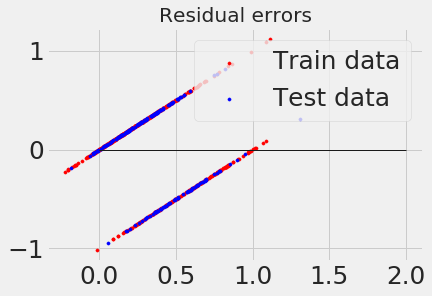

Mean Absolute Error (MAE)         : 0.34578735153923384
Mean Squared Error (MSE) : 0.1628126636019737
Root Mean Squared Error (RMSE) : 0.4035005125176097
Root Mean Squared Error (RMSE) : 0.4035005125176097
Mean Absolute Perc. Error (MAPE) : inf


In [59]:
# Rescale the cleaned feature matrix to the [0, 1] range with MinMaxScaler
da2 = da.values
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(da2)
MinMaxScaler_X = scaler.transform(da2)
df = pd.read_csv("diabetes.csv")
df.head()
df.drop( df[ df['Glucose'] == 0 ].index , inplace=True)
df.drop( df[ df['BloodPressure'] == 0 ].index , inplace=True)

df= pd.DataFrame(da2,columns=["Pregnancies", "Glucose", "BloodPressure", 'SkinThickness',"Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"])
X = df[["Pregnancies", "Glucose","Insulin","BMI","DiabetesPedigreeFunction"]]
y = df["Outcome"]
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y) 
reg = linear_model.LinearRegression() 
reg.fit(X_train, y_train)  
print('Coefficients: \n', reg.coef_) 
print('Variance score: {}'.format(reg.score(X_test, y_test))) 
plt.style.use('fivethirtyeight') 
plt.scatter(reg.predict(X_train), reg.predict(X_train) - y_train,color = "red", s = 10, label = 'Train data')  
plt.scatter(reg.predict(X_test), reg.predict(X_test) - y_test,color = "blue", s = 10, label = 'Test data') 
plt.hlines(y = 0, xmin = 0, xmax = 2, linewidth = 1) 
plt.legend(loc = 'upper right') 
plt.title("Residual errors") 
plt.show() 
y_preds = reg.predict(X_test)
print("Mean Absolute Error (MAE)         : {}".format(mean_absolute_error(y_test, y_preds)))
print("Mean Squared Error (MSE) : {}".format(mse(y_test, y_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y_test, y_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y_test, y_preds)))
print("Mean Absolute Perc. Error (MAPE) : {}".format(np.mean(np.abs((y_test - y_preds) / y_test)) * 100))

## Standard Scaling (exercise 10-4)

Coefficients: 
 [ 2.11768433e-02  6.92173929e-03 -1.58977902e-04  1.08755877e-02
  2.15112892e-01]
Variance score: 0.3051742288887802


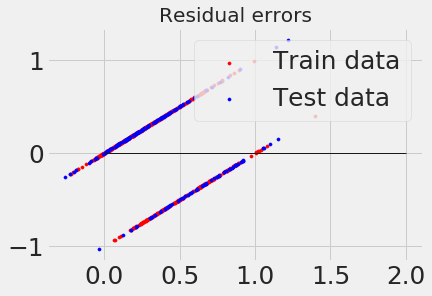

Mean Absolute Error (MAE)         : 0.3216619138440027
Mean Squared Error (MSE) : 0.15726086239647433
Root Mean Squared Error (RMSE) : 0.3965612971489708
Root Mean Squared Error (RMSE) : 0.3965612971489708
Mean Absolute Perc. Error (MAPE) : inf


In [58]:
# Standardize the cleaned feature matrix to zero mean and unit variance
da3 = da.values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(da3)
standardized_X = scaler.transform(da3)
df = pd.read_csv("diabetes.csv")
df.head()
df.drop( df[ df['Glucose'] == 0 ].index , inplace=True)
df.drop( df[ df['BloodPressure'] == 0 ].index , inplace=True)

df= pd.DataFrame(da3,columns=["Pregnancies", "Glucose", "BloodPressure", 'SkinThickness',"Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"])
X = df[["Pregnancies", "Glucose","Insulin","BMI","DiabetesPedigreeFunction"]]
y = df["Outcome"]
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y) 
reg = linear_model.LinearRegression() 
reg.fit(X_train, y_train)  
print('Coefficients: \n', reg.coef_) 
print('Variance score: {}'.format(reg.score(X_test, y_test))) 
plt.style.use('fivethirtyeight') 
plt.scatter(reg.predict(X_train), reg.predict(X_train) - y_train, color = "red", s = 10, label = 'Train data') 
plt.scatter(reg.predict(X_test), reg.predict(X_test) - y_test,color = "blue", s = 10, label = 'Test data')   
plt.hlines(y = 0, xmin = 0, xmax = 2, linewidth = 1)   
plt.legend(loc = 'upper right') 
plt.title("Residual errors") 
plt.show() 
y_preds = reg.predict(X_test)
print("Mean Absolute Error (MAE)         : {}".format(mean_absolute_error(y_test, y_preds)))
print("Mean Squared Error (MSE) : {}".format(mse(y_test, y_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y_test, y_preds)))
print("Root Mean Squared Error (RMSE) : {}".format(rmse(y_test, y_preds)))
print("Mean Absolute Perc. Error (MAPE) : {}".format(np.mean(np.abs((y_test - y_preds) / y_test)) * 100))


## Train/Test Split (exercise 11-2)

In [92]:
# Split the cleaned, scaled data into train and test sets
from sklearn.model_selection import train_test_split
Y=df["Outcome"]

X=df[[ "Pregnancies", "Glucose", "BloodPressure", 'SkinThickness',"Insulin","BMI","DiabetesPedigreeFunction","Age"]]
Xtr, Xte, ytr,yte = train_test_split(X, Y,test_size = 0.2)
Xtr.shape

(582, 8)

## Note (exercise 11-3 — no content in the original notebook)